In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df=pd.read_csv('../preprocessing/imputed_data.csv')

In [3]:
df['price']= df['price']/1.0e+7

#### Categorizing Luxury score & Floor

<Axes: xlabel='luxury_score'>

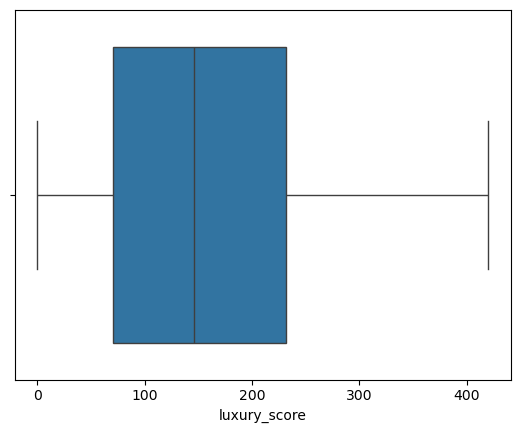

In [4]:
sns.boxplot(x=df['luxury_score'])

In [5]:
def luxury_category(score):
    if 0<=score<100:
        return "Low"
    elif 100 <=score<300:
        return "Medium"
    elif 300<= score:
        return "High"
    else :
        return None
    
df['luxury_category'] = df['luxury_score'].apply(luxury_category)

In [6]:
pd.set_option('display.max_columns', None)
df.head()

,price,price_per_sqft,carpet_area,facing,ownership,bedrooms,bathrooms,balcony,floor,furnish_type,prop_type,city,luxury_score,Others,Servant Room,Study Room,Pooja Room,Store Room,ageing,location_area,luxury_category
0,6.90,63186.0,1092.0,North-East,Freehold,3.0,3.0,0.0,30.0,Semifurnished,Flat,Mumbai,300,1,0,0,1,0,Relatively New,Parel,High
1,4.50,38986.0,1051.0,North-East,Co-operative Society,3.0,3.0,0.0,8.0,Unfurnished,Flat,Mumbai,268,0,0,0,0,0,Relatively Old,Ghatkopar,Medium
2,7.30,40109.0,1081.0,North-East,Freehold,3.0,3.0,2.0,0.0,Semifurnished,Flat,Mumbai,310,0,0,0,0,1,Relatively Old,Goregaon,High
3,1.56,32098.0,486.0,East,Freehold,2.0,2.0,0.0,10.0,Unfurnished,Flat,Mumbai,60,0,0,0,0,0,New,Kandivali,Low
4,1.43,18333.0,625.0,East,Freehold,2.0,2.0,0.0,1.0,Unfurnished,Flat,Mumbai,188,0,0,0,0,0,Old,Mulund,Medium


<Axes: xlabel='floor'>

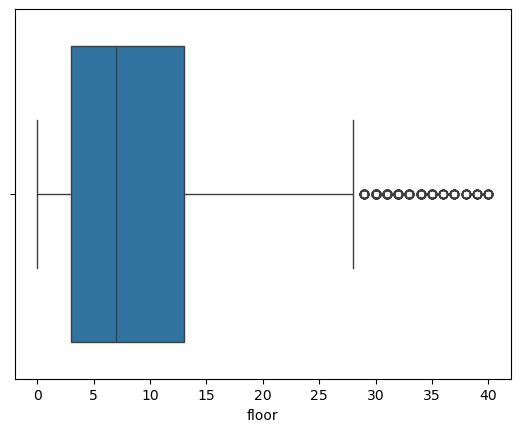

In [7]:
sns.boxplot(x=df['floor'])

In [8]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor:
        return "High Floor"
    else:
        return None  

In [9]:
df['floor_category']=df['floor'].apply(categorize_floor)
df.head()

,price,price_per_sqft,carpet_area,facing,ownership,bedrooms,bathrooms,balcony,floor,furnish_type,prop_type,city,luxury_score,Others,Servant Room,Study Room,Pooja Room,Store Room,ageing,location_area,luxury_category,floor_category
0,6.90,63186.0,1092.0,North-East,Freehold,3.0,3.0,0.0,30.0,Semifurnished,Flat,Mumbai,300,1,0,0,1,0,Relatively New,Parel,High,High Floor
1,4.50,38986.0,1051.0,North-East,Co-operative Society,3.0,3.0,0.0,8.0,Unfurnished,Flat,Mumbai,268,0,0,0,0,0,Relatively Old,Ghatkopar,Medium,Mid Floor
2,7.30,40109.0,1081.0,North-East,Freehold,3.0,3.0,2.0,0.0,Semifurnished,Flat,Mumbai,310,0,0,0,0,1,Relatively Old,Goregaon,High,Low Floor
3,1.56,32098.0,486.0,East,Freehold,2.0,2.0,0.0,10.0,Unfurnished,Flat,Mumbai,60,0,0,0,0,0,New,Kandivali,Low,Mid Floor
4,1.43,18333.0,625.0,East,Freehold,2.0,2.0,0.0,1.0,Unfurnished,Flat,Mumbai,188,0,0,0,0,0,Old,Mulund,Medium,Low Floor


In [10]:
df.drop(columns=['floor','luxury_score','price_per_sqft'],inplace=True)
df['facing'].fillna("Missing",inplace=True)

C:\Users\91892\AppData\Local\Temp\ipykernel_5168\915236010.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna("Missing",inplace=True)


In [12]:
df['facing'].value_counts()

facing
East          2916
Missing       1754
West          1278
North-East     835
North          719
North-West     335
South          285
South-West     226
South-East     225
Name: count, dtype: int64

In [86]:
from sklearn.preprocessing import OrdinalEncoder
df_encoded = df.copy()
cat_cols=df.select_dtypes(include=['object']).columns

for col in cat_cols:
    oe = OrdinalEncoder()
    df_encoded[col]=oe.fit_transform(df_encoded[[col]])
    print(oe.categories_)

[array(['East', 'Missing', 'North', 'North-East', 'North-West', 'South',
       'South-East', 'South-West', 'West'], dtype=object)]
[array(['Co-operative Society', 'Freehold', 'Leasehold',
       'Power of Attorney'], dtype=object)]
[array(['Furnished', 'Semifurnished', 'Unfurnished'], dtype=object)]
[array(['Flat', 'House'], dtype=object)]
[array(['Mumbai', 'Navi Mumbai', 'Thane'], dtype=object)]
[array(['New', 'Old', 'Relatively New', 'Relatively Old', 'Undefined',
       'Under Construction'], dtype=object)]
[array(['Agripada', 'Airoli', 'Andheri', 'Bandra', 'Belapur', 'Bhandup',
       'Bhiwandi', 'Borivali', 'Byculla', 'Byculla-Mazgaon', 'Chembur',
       'Colaba', 'Cumbala Hill', 'Dadar', 'Dahisar', 'Diva', 'Ghansoli',
       'Ghatkopar', 'Girgaon', 'Goregaon', 'Grant Road', 'Jogeshwari',
       'Juhu', 'Kalamboli', 'Kalyan-Dombivli', 'Kamothe', 'Kandivali',
       'Kanjurmarg', 'Karjat', 'Khanda Colony', 'Khar', 'Kharghar',
       'Kurla', 'Mahim', 'Malad', 'Mandvi-Bhuleshwar', 

In [87]:
X=df_encoded.drop('price',axis=1)
y=df_encoded['price']

#### Technique 1: Correlation 

<Axes: >

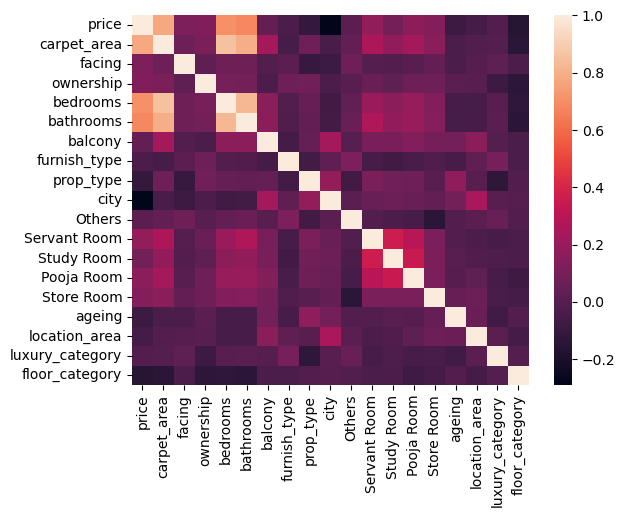

In [88]:
sns.heatmap(df_encoded.corr())

In [89]:
fi_df1 = df_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,carpet_area,0.777488
1,facing,0.119563
2,ownership,0.130252
3,bedrooms,0.703435
4,bathrooms,0.677998
5,balcony,0.040033
6,furnish_type,-0.032486
7,prop_type,-0.113065
8,city,-0.290153
9,Others,0.017646


#### Technique 2 Random Forest

In [90]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X,y)

fi_df2 = pd.DataFrame({'feature':X.columns,
                       'rf_imp':rf.feature_importances_}).sort_values(by='rf_imp',ascending=False)
fi_df2

,feature,rf_imp
0,carpet_area,0.667062
15,location_area,0.097668
8,city,0.085481
7,prop_type,0.026036
14,ageing,0.016855
5,balcony,0.016453
1,facing,0.013873
3,bedrooms,0.013409
4,bathrooms,0.013063
6,furnish_type,0.009902


#### Technique 2 GB

In [91]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor()
gb.fit(X,y)

fi_df3 = pd.DataFrame({'feature':X.columns,
                       'gb_imp':gb.feature_importances_}).sort_values(by='gb_imp',ascending=False)
fi_df3

,feature,gb_imp
0,carpet_area,0.686557
15,location_area,0.097905
8,city,0.092808
4,bathrooms,0.043674
3,bedrooms,0.034764
7,prop_type,0.032152
5,balcony,0.004269
17,floor_category,0.001686
14,ageing,0.001595
13,Store Room,0.000903


In [92]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train,y_train)

perm_imp=permutation_importance(rf,x_test,y_test,n_repeats=30,random_state=42)



In [93]:
fi_df4 = pd.DataFrame({'feature':X.columns,
                       'permutation_importance':perm_imp.importances_mean}).sort_values(by='permutation_importance',ascending=False)
fi_df4

,feature,permutation_importance
0,carpet_area,1.011734
8,city,0.178978
15,location_area,0.125168
7,prop_type,0.034494
3,bedrooms,0.030974
4,bathrooms,0.019702
5,balcony,0.013731
14,ageing,0.010777
1,facing,0.005810
2,ownership,0.004595


In [94]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y)

fi_df5 = pd.DataFrame({
    'feature': X.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
0,carpet_area,1.237748
4,bathrooms,0.217557
2,ownership,0.051299
3,bedrooms,0.049807
1,facing,0.039139
13,Store Room,0.036914
15,location_area,0.028154
10,Servant Room,0.018672
12,Pooja Room,0.007820
6,furnish_type,-0.000000


In [95]:
from sklearn.feature_selection import RFE

estimator = RandomForestRegressor()
selector_label = RFE(estimator, n_features_to_select=X.shape[1], step=1)
selector_label = selector_label.fit(X, y)

selected_features = X.columns[selector_label.support_]
selected_coefficients = selector_label.estimator_.feature_importances_

fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
0,carpet_area,0.668193
15,location_area,0.097194
8,city,0.085053
7,prop_type,0.026327
14,ageing,0.017090
5,balcony,0.016626
1,facing,0.014177
3,bedrooms,0.013405
4,bathrooms,0.013403
6,furnish_type,0.009888


In [96]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
0,carpet_area,1.239427
4,bathrooms,0.220386
2,ownership,0.058070
3,bedrooms,0.054360
1,facing,0.046654
13,Store Room,0.043158
15,location_area,0.042209
10,Servant Room,0.031356
12,Pooja Room,0.018151
14,ageing,-0.007832


In [97]:
# !pip install shap

In [98]:
import shap 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
explainer = shap.TreeExplainer(rf)
shap_values=explainer.shap_values(X)
shap_sum = np.abs(shap_values).mean(axis=0)

fi_df8 = pd.DataFrame({'features':X.columns,
                       'shap_values':shap_sum}).sort_values(by="shap_values",ascending=False)

In [107]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')


In [108]:
for i, df in enumerate([fi_df1, fi_df2, fi_df3, fi_df4, fi_df5, fi_df6, fi_df7, fi_df8], start=1):
    print(f"fi_df{i} columns: {df.columns.tolist()}")


fi_df1 columns: ['feature', 'corr_coeff']
fi_df2 columns: ['feature', 'rf_imp']
fi_df3 columns: ['feature', 'gb_imp']
fi_df4 columns: ['feature', 'permutation_importance']
fi_df5 columns: ['feature', 'lasso_coeff']
fi_df6 columns: ['feature', 'rfe_score']
fi_df7 columns: ['feature', 'reg_coeffs']
fi_df8 columns: ['feature', 'shap_values']


In [109]:
fi_df8 = fi_df8.rename(columns={"features": "feature"})

In [110]:
# Select only numeric columns
numeric_cols = final_fi_df.select_dtypes(include=['number']).columns

# Normalize only numeric columns
final_fi_df[numeric_cols] = final_fi_df[numeric_cols].divide(final_fi_df[numeric_cols].sum(axis=0), axis=1)


In [111]:
final_fi_df

,corr_coeff,rf_imp,gb_imp,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,shap_values
feature,,,,,,,,
carpet_area,0.336212,0.667062,0.686557,0.697178,1.661098,0.668193,1.725143,0.514603
facing,0.051703,0.013873,0.000830,0.004004,0.052526,0.014177,0.064938,0.013708
ownership,0.056325,0.007183,0.000544,0.003167,0.068844,0.006990,0.080827,0.007952
bedrooms,0.304189,0.013409,0.034764,0.021344,0.066843,0.013405,0.075663,0.036525
bathrooms,0.293189,0.013063,0.043674,0.013576,0.291969,0.013403,0.306753,0.026605
balcony,0.017311,0.016453,0.004269,0.009462,-0.216182,0.016626,-0.242531,0.025430
furnish_type,-0.014048,0.009902,0.000555,0.002620,-0.000000,0.009888,-0.014682,0.011601
prop_type,-0.048893,0.026036,0.032152,0.023770,-0.312505,0.026327,-0.338913,0.036454
city,-0.125472,0.085481,0.092808,0.123332,-0.511058,0.085053,-0.538427,0.163978


In [112]:
final_fi_df[['rf_imp','gb_imp','permutation_importance','rfe_score','shap_values']].mean(axis=1).sort_values(ascending=False)

feature
carpet_area        0.646719
city               0.110131
location_area      0.097907
prop_type          0.028948
bedrooms           0.023889
bathrooms          0.022064
balcony            0.014448
ageing             0.012118
facing             0.009318
furnish_type       0.006913
floor_category     0.006298
ownership          0.005167
luxury_category    0.004653
Store Room         0.004278
Others             0.002295
Pooja Room         0.001996
Study Room         0.001485
Servant Room       0.001374
dtype: float64

In [113]:
from sklearn.model_selection import cross_val_score
rfe = RandomForestRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
scores.mean()

np.float64(0.7997266796497714)

In [162]:
export = df.drop(columns=['Servant Room','Study Room','Pooja Room','Others','ownership'])
export['price']= df['price']
export.shape

(8573, 14)

In [163]:
export.to_csv('feature_selection_data.csv',index=False)